In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.fluid      import Fluid
from src.interpolator import LinearInterpolator

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True

In [5]:
M = 0.016
T_res = 310.0
df = pd.read_csv('hw2_data.csv', sep=';')
xa = df['xa, mol. %'].iloc[15]
xy = df['xy, mol. %'].iloc[15]
rho_c = df['rho_c, kg/m3'].iloc[15]

fluid = Fluid(M=M, rho_c=rho_c, xa=xa, xy=xy, T=T_res)

# Раздел 1 — Модель PVT

Графики Z(P), Bg(P), mu(P), ρ(P) в диапазоне 1–200 атм.

Сравнение ρ_ideal vs ρ_real

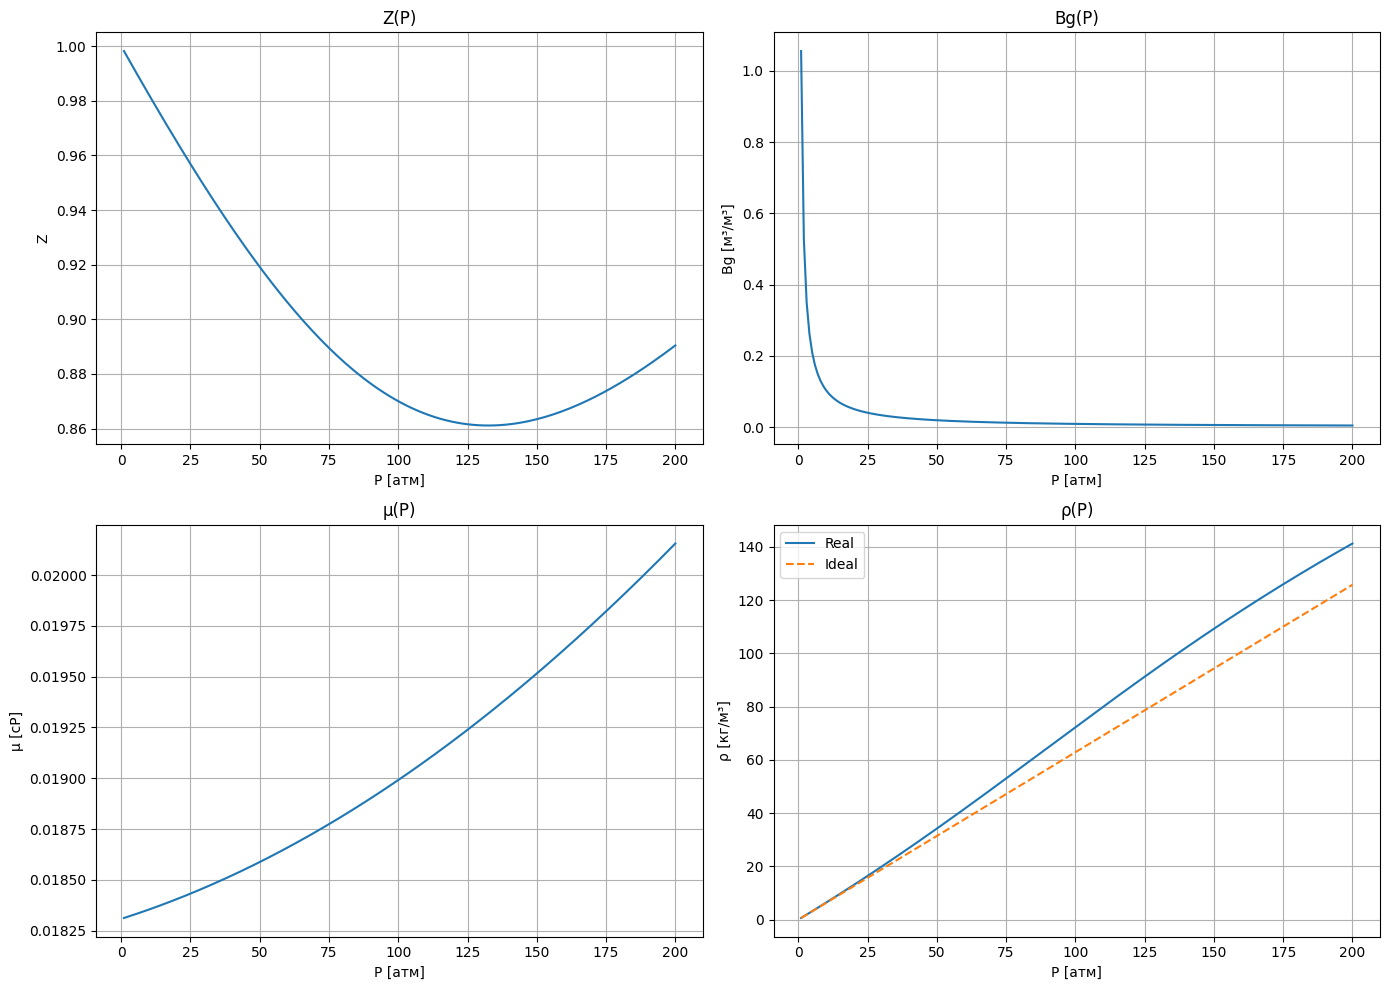

In [6]:
P_range = np.linspace(1, 200, 200)

Z_vals   = [fluid.z(P)   for P in P_range]
Bg_vals  = [fluid.bg(P)  for P in P_range]
mu_vals  = [fluid.mu(P)  for P in P_range]
rho_vals = [fluid.ro(P)  for P in P_range]

R = 8.314
rho_ideal = [P * 101325 * M / (1.0 * R * T_res) for P in P_range]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#Графики Z(P), Bg(P), mu(P)
axes[0,0].plot(P_range, Z_vals);   axes[0,0].set(title='Z(P)', xlabel='P [атм]', ylabel='Z')
axes[0,1].plot(P_range, Bg_vals);  axes[0,1].set(title='Bg(P)', xlabel='P [атм]', ylabel='Bg [м³/м³]')
axes[1,0].plot(P_range, mu_vals);  axes[1,0].set(title='μ(P)', xlabel='P [атм]', ylabel='μ [cP]')
#ρ(P), cравнение ρ_ideal vs ρ_real
axes[1,1].plot(P_range, rho_vals, label='Real')
axes[1,1].plot(P_range, rho_ideal, '--', label='Ideal')
axes[1,1].set(title='ρ(P)', xlabel='P [атм]', ylabel='ρ [кг/м³]')
axes[1,1].legend()

plt.tight_layout()
plt.show()